[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/PerformanceEstimation/PEPit/blob/master/ressources/demo/PEPit_demo_extract_worst_case_examples.ipynb)

# PEPit : numerical identification of worst-case examples

In this lab we cover:
- A simple example illustrating how to obtain a worst-case instance for **gradient descent** (when minimizing a smooth convex function) using the PEPit package.
- Two other examples illustrating how to obtain worst-case instances in other situations: with proximal operators, momentum, possibly non-convex functions, and primal-dual methods.

For a first demo of PEPit, including detailed installation, imports, and basic introductory steps, we refer to the introductory [demo](https://colab.research.google.com/github/bgoujaud/PEPit/blob/master/ressources/demo/PEPit_demo.ipynb) file.


This notebook considers the following three algorithms:
* [Example 1](#example1) : **gradient descent** for smooth convex minimization (1D examples).
* [Example 2](#example3) : **gradient descent** for smooth possibly non-convex minimization (1D examples).
* [Example 3](#example6) : **gradient descent with exact line-search** for smooth strongly convex minimization (2D examples).



You can find more examples at [Pepit demos](https://github.com/PerformanceEstimation/PEPit/blob/master/ressources/demo/PEPit_demo_extract_worst_case_examples.ipynb)


**Import a few necessary common Python packages (numpy, matplotlib)**

In [2]:
import numpy as np
import matplotlib
matplotlib.rcParams.update({
    "mathtext.fontset": "cm",   # LaTeX font for rendering equations in plots
    "legend.fontsize": 12,
    "axes.labelsize": 14
})
import matplotlib.pyplot as plt

from math import sqrt

<a id="toc"></a>
## Table of Contents
- [1. Gradient descent for smooth convex minimization](#example1)
- [2. Gradient descent for smooth possibly non-convex minimization](#example3)
- [3. Gradient descent with exact line-search](#example6)

We re-implement some basic examples below. This is necessary as we will save the worst-case trajectories.

## Example 1 : gradient descent for smooth convex minimization <a class="anchor" id="example1"></a>

We consider the following convex minimization problem:
\begin{equation}
f_\star \triangleq \min_x f(x),
\end{equation}
where $f$ is $L$-smooth and convex.

For this example, we consider the problem of computing the smallest possible $\tau(n, L, \gamma)$ such that the following guarantee holds (for any initialization of the algorithm, and any $L$-smooth convex functions)
\begin{equation}
f(x_n)-f_\star \leqslant \tau(n, L, \gamma) \| x_0 - x_\star \|^2,
\end{equation}
where $x_n$ is the output of gradient descent with fixed step size $\gamma$, started from $x_0$, and where $x_\star$ is a minimizer of $f$.

#### Algorithm

Gradient descent with fixed step size $\gamma$ may be described as follows, for $t \in \{0,1, \ldots, n-1\}$
\begin{equation}
x_{t+1} = x_t - \gamma \nabla f(x_t).
\end{equation}


#### Low-dimensional worst-case examples

The solution to the PEP provides an example trajectory of points that would result in a worst-case convergence rate. In general, worst-case examples are non-unique in different ways: there are generally many trajectories of points that result in worst-case performance, and there are generally multiple different functions that can interpolate the same trajectory. Using a solution to the PEP, one can identify the dimension of a matching worst-case instance by inspection of the rank of the Gram matrix. More precisely, the rank of the Gram matrix corresponds to the dimension of the matching worst-case example (see, e.g., [here, Section 3.2](https://arxiv.org/pdf/1502.05666)).

PEPit contains a few heuristics to try to identify such low-dimensional worst-case instances, by searching for low-rank Gram matrices. There are two of them: the trace heuristic ($\ell_1$ on the eigenvalues) and the logdet heuristic---applying gradient descent on the logdet of the Gram matrix $G$, which corresponds to a reweighted $\ell_1$ on the eigenvalues of $G$. For both of them, we need to potentially leave some slack in the objective, which we fix here to `tol_dimension_reduction=1e-6`.

In [4]:
# !pip install pepit (enough for colab)
!pip install --force-reinstall pepit==0.5.0 # might be needed if you have a local install already (enough for colab)

  Using cached pepit-0.5.0-py3-none-any.whl.metadata (39 kB)
  Using cached cvxpy-1.8.1-cp311-cp311-macosx_10_9_universal2.whl.metadata (9.6 kB)
  Using cached pandas-3.0.1-cp311-cp311-macosx_11_0_arm64.whl.metadata (79 kB)
  Using cached osqp-1.1.1-cp311-cp311-macosx_11_0_arm64.whl.metadata (2.2 kB)
  Using cached clarabel-0.11.1-cp39-abi3-macosx_11_0_arm64.whl.metadata (4.8 kB)
  Using cached scs-3.2.11-cp311-cp311-macosx_11_0_arm64.whl.metadata (2.8 kB)
  Using cached numpy-2.4.3-cp311-cp311-macosx_14_0_arm64.whl.metadata (6.6 kB)
  Using cached scipy-1.17.1-cp311-cp311-macosx_14_0_arm64.whl.metadata (62 kB)
  Using cached highspy-1.13.1-cp311-cp311-macosx_11_0_arm64.whl.metadata (11 kB)
  Using cached cffi-2.0.0-cp311-cp311-macosx_11_0_arm64.whl.metadata (2.6 kB)
  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached setuptools-82.0.1-py3-none-any.whl.metadata (6.5 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached python_dateut

In [5]:
from PEPit import PEP
from PEPit.functions import SmoothStronglyConvexFunction

L = 1
gamma = 1/L
n = 4
verbose = 1


# Instantiate PEP
problem = PEP()

# Declare a smooth strongly convex function
f = problem.declare_function(SmoothStronglyConvexFunction, L=L,mu=0)

# Then define the starting point x0 of the algorithm as well as corresponding gradient and function value g0 and f0
x0 = problem.set_initial_point()
g0, f0 = f.oracle(x0)

xs = f.stationary_point()
gs, fs = f.oracle(xs)

# Prepare empty lists for saving all datapoints
x_list = list()
g_list = list()
f_list = list()

# Run n steps of GD method with step-size gamma
gx, fx = g0, f0

x_list.append(x0)
g_list.append(g0)
f_list.append(f0)

for i in range(n):
    x_list.append(x_list[-1] - gamma * gx)
    gx, fx = f.oracle(x_list[-1])
    g_list.append(gx)
    f_list.append(fx)

# Set initial condition and performance metric
problem.set_initial_condition((x0-xs)**2 <= 1)
problem.set_performance_metric(f_list[-1] - fs)

# Solve the PEP
pepit_verbose = max(verbose, 0)
pepit_tau = problem.solve(verbose=pepit_verbose, dimension_reduction_heuristic="logdet2", tol_dimension_reduction=1e-6)

ImportError: cannot import name compose_quat

As we can see from the output, PEPit identified a low-rank matrix where all eigenvalues (except one) is approximately equal to 0. This corresponds to a single-dimensional worst-case example.
In order to evaluate and plot a worst-case trajectory, we use the `eval` function on the iterates, their gradients, and function values. Since we want to visualize the worst-case in 1D, we trim the dimension to only the first components.

In [27]:
# Evaluate the iterations:

x_list_evaluated = [x.eval()[0] for x in x_list] # [0] is because we are interested in largest component only
g_list_evaluated = [g.eval()[0] for g in g_list] # same
f_list_evaluated = [f.eval() for f in f_list]

# Evaluate specific points (for better visualization later)
xs_evaluated = xs.eval()[0] # x*
gs_evaluated = gs.eval()[0] # g(x*)=0
fs_evaluated = fs.eval() # f(x*)

x0_evaluated = x0.eval()[0] # x0
g0_evaluated = g0.eval()[0] # g(x0)
f0_evaluated = f0.eval() # f(x0)

Now, using the list of iterates, we can simply plot the trajectory (in terms of $(x,f(x))$ as follows:

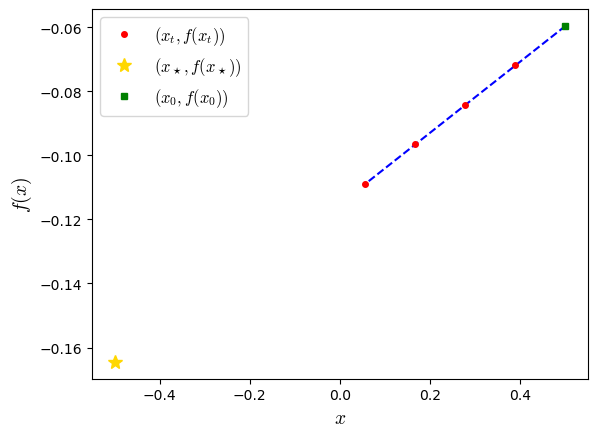

In [28]:
plt.plot(x_list_evaluated, f_list_evaluated, '.--', color='blue')

plt.plot(x_list_evaluated, f_list_evaluated, marker='.', color='red',  linestyle='none', markersize=8, label='$(x_t,f(x_t))$')
plt.plot(xs_evaluated, fs_evaluated, marker='*', color='gold', linestyle='none', markersize=10, label=r'$(x_\star,f(x_\star))$')
plt.plot(x0_evaluated, f0_evaluated, marker='s', color='green', linestyle='none', markersize=5, label=r'$(x_0,f(x_0))$')


plt.legend()
plt.xlabel('$x$')
plt.ylabel('$f(x)$')

plt.show()

The last plot is giving a partial picture of what a worst-case function might look like: the function is evaluated only at a few points (iterates & an optimal point).

For this reason, we provide a few tools that allows extrapolating within certain classes of functions. This is done via the "interpolator" classes (that internally formulate the interpolation problems for a few classes).

The interpolator that corresponds to the PEP under consideration can be obtained (when implemented for the corresponding class) as follows (possibly with a few options):

In [ ]:
feval = f.get_interpolator()

ImportError: cannot import name compose_quat

Now, we can evaluate an interpolating function on a grid of points "x_test" around the iterates and the solution.

In [9]:
# Create a grid of points where an interpolating function should be computed:
nb_pts_grid = 100
x_min = np.min([x0_evaluated,xs_evaluated])
x_max = np.max([x0_evaluated,xs_evaluated])
x_test = np.linspace(x_min,x_max,nb_pts_grid)

# Use the interpolation tools: evaluate a function using the "feval" interpolator on the grid:
fx_test = np.zeros(x_test.shape)
for i in range(len(x_test)):
    fx_test[i] = feval(np.array([x_test[i]]))
    print(f'{i + 1} / {len(x_test)} grid points computed', end='\r', flush=True)

... which we can now plot!

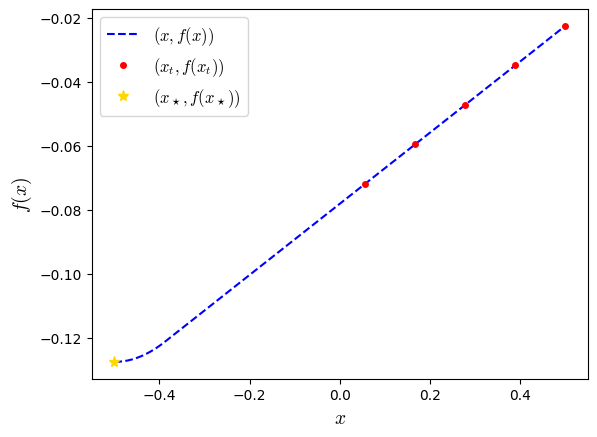

In [10]:
#plt.plot(x_list_evaluated[::1,], f_list_evaluated, '.--', color='blue')
plt.plot(x_test, fx_test, '--', color='blue', label='$(x,f(x))$')
plt.plot(x_list_evaluated, f_list_evaluated, marker='.', color='red',  linestyle='none', markersize=8, label='$(x_t,f(x_t))$')
plt.plot(xs_evaluated, fs_evaluated, marker='*', color='gold', linestyle='none', markersize=8, label=r'$(x_\star,f(x_\star))$')


plt.legend()
plt.xlabel('$x$')
plt.ylabel('$f(x)$')

plt.show()

We observe a trajectory that looks like a type of Huber loss function, as predicted by the proof of Theorem 3.2 from [this paper](https://arxiv.org/pdf/1206.3209).

<div align="right"><a href="#toc">↩ Back to TOC</a></div>

<div align="right"><a href="#toc">↩ Back to TOC</a></div>

## Example 2 : gradient descent for potentially non-convex minimization <a class="anchor" id="example3"></a>

We consider the following convex minimization problem:
\begin{equation}
f_\star \triangleq \min_x f(x),
\end{equation}
where $f$ is $L$-smooth (and potentially non-convex).

For this example, we consider the problem of computing the smallest possible $\tau(n, L, \mu, \gamma)$ such that the following guarantee holds (for any initialization of the algorithm, and any $L$-smooth function)
\begin{equation}
\min_{0\leq t\leq n} \|\nabla f(x_t)\|^2 \leqslant \tau(n, L, \gamma) (f(x_0)-f(x_\star)),
\end{equation}
where $x_t$ are the iterates gradient descent with step size $\gamma$, started from $x_0$:
\begin{equation}
x_{t+1} = x_t - \gamma \nabla f(x_t),
\end{equation}
and where $x_\star$ is a stationary point such that $f(x_\star)\leq f(x_t)$ for all $t=0,1,\ldots,n$.


In [ ]:
from PEPit import PEP
from PEPit.functions import SmoothFunction

L = 1
n = 3
gamma = .95/L
verbose = 1


# Instantiate PEP
problem = PEP()

# Declare a smooth strongly convex function
f = problem.declare_function(SmoothFunction, L=L) #TODO OPERAND

# Then define the starting point x0 of the algorithm as well as corresponding gradient and function value g0 and f0
x0 = problem.set_initial_point()
g0, f0 = f.oracle(x0)

xs = f.stationary_point()
gs, fs = f.oracle(xs)

# Run n steps of GD method with step-size gamma
x_list = list()
g_list = list()
f_list = list()
gx, fx = g0, f0

x_list.append(x0)
f_list.append(f0)
g_list.append(g0)

for i in range(n):
    # Set the performance metric to the minimum of the gradient norm over the iterations
    problem.set_performance_metric(gx**2) 
    f.add_constraint(fs <= fx - 1/2/L * gx**2)
    x_list.append(x_list[-1] - gamma * gx)
    gx, fx = f.oracle(x_list[-1])
    f_list.append(fx)
    g_list.append(gx)
problem.set_performance_metric(gx**2)
f.add_constraint(fs <= fx - 1/2/L * gx**2)

# Set initial condition
problem.set_initial_condition( f0 - fs == 1) #TODO OPERAND

# Solve the PEP
pepit_verbose = max(verbose, 0)
pepit_tau = problem.solve(verbose=pepit_verbose, dimension_reduction_heuristic="logdet3", tol_dimension_reduction=1e-6) #TODO OPERAND

(PEPit) Setting up the problem: performance measure is the minimum of 4 element(s)
(PEPit) Setting up the problem: Adding initial conditions and general constraints ...
(PEPit) Setting up the problem: initial conditions and general constraints (1 constraint(s) added)
(PEPit) Setting up the problem: interpolation conditions for 1 function(s)
			Function 1 : Adding 20 scalar constraint(s) ...
			Function 1 : 20 scalar constraint(s) added
(PEPit) Setting up the problem: additional constraints for 1 function(s)
			Function 1 : Adding 4 scalar constraint(s) ...
			Function 1 : 4 scalar constraint(s) added
(PEPit) Setting up the problem: size of the Gram matrix: 6x6
(PEPit) Compiling SDP
(PEPit) Calling SDP solver
(PEPit) Solver status: optimal (wrapper:cvxpy, solver: SCS); optimal value: 0.37409407649497745
(PEPit) Postprocessing: 2 eigenvalue(s) > 3.321138366120591e-06 before dimension reduction
(PEPit) Calling SDP solver
(PEPit) Solver status: optimal_inaccurate (solver: SCS); objective v

Again: PEPit claims to have found a 1D counterexample, so we focus on the first coordinates of the output.

In [20]:
# Evaluate the coordinate, gradient, and function values
x_list_evaluated = [x.eval()[0] for x in x_list]
g_list_evaluated = [g.eval()[0] for g in g_list]
f_list_evaluated = [f.eval() for f in f_list]

# Evaluate a specific point (x*):
xs_evaluated = xs.eval()[0] # x*
fs_evaluated = fs.eval() # f(x*)
gs_evaluated = gs.eval()[0] # g(x*)

Let us now obtain the interpolator and use it to visualize a worst-case instance!

In [ ]:
# get an interpolator
feval = f.get_interpolator() #TODO OPERAND


# Create a grid of points where an interpolating function for f() should be computed:
nb_pts_grid = 100 # number of points on the grid
margin = .2 # extrapolate outside only evaluated points

x_min = np.min([np.min(x_list_evaluated),xs_evaluated])
x_max = np.max([np.max(x_list_evaluated),xs_evaluated])
x_test = np.linspace(x_min-margin,x_max+margin,nb_pts_grid)

fx_test = np.zeros(x_test.shape)
# Interpolate on the grid!
for i in range(len(x_test)):
    fx_test[i] = feval(np.array([x_test[i]]))
    print(f'{i + 1} / {len(x_test)} grid points computed', end='\r', flush=True)


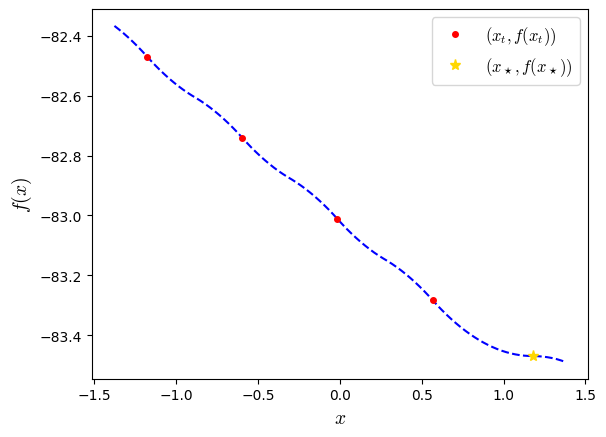

In [22]:
plt.plot(x_test, fx_test, '--', color='blue')
plt.plot(x_list_evaluated, f_list_evaluated, marker='.', color='red',  linestyle='none', markersize=8, label=r'$(x_t,f(x_t))$')
plt.plot(xs_evaluated, fs_evaluated, marker='*', color='gold', linestyle='none', markersize=8, label=r'$(x_\star,f(x_\star))$')


plt.legend()
plt.xlabel('$x$')
plt.ylabel('$f(x)$')

plt.show()

A natural question now is whether this interpolator is actually unique. In fact, it is not in general. In PEPit, the default interpolator is often the one that creates the *lowest possible* interpolating function (the one that results in points with the *smallest possible function value*), but one can configure the interpolator to do the opposite (as we shall see in the next example).

In [23]:
# get an interpolator
feval = f.get_interpolator(options='highest')


# Create a grid of points where an interpolating function for f() should be computed:
nb_pts_grid = 100 # number of points on the grid
margin = .2 # extrapolate outside only evaluated points

x_min = np.min([np.min(x_list_evaluated),xs_evaluated])
x_max = np.max([np.max(x_list_evaluated),xs_evaluated])
x_test = np.linspace(x_min-margin,x_max+margin,nb_pts_grid)

fx_test = np.zeros(x_test.shape)
# Interpolate on the grid!
for i in range(len(x_test)):
    fx_test[i] = feval(np.array([x_test[i]]))
    print(f'{i + 1} / {len(x_test)} grid points computed', end='\r', flush=True)


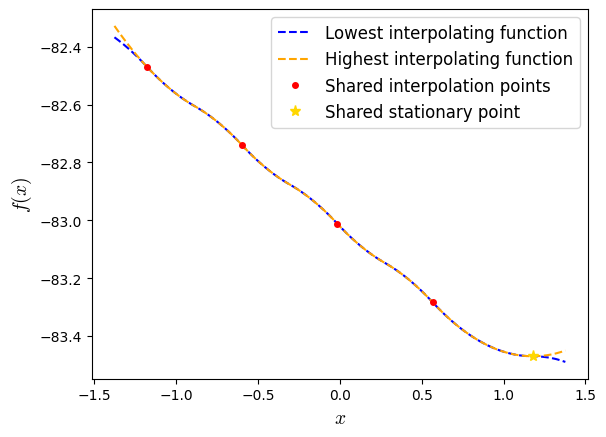

In [24]:
feval_lowest = f.get_interpolator()
fx_test_lowest = np.array([feval_lowest(np.array([x])) for x in x_test])

plt.plot(x_test, fx_test_lowest, '--', color='blue', label='Lowest interpolating function')
plt.plot(x_test, fx_test, '--', color='orange', label='Highest interpolating function')
plt.plot(x_list_evaluated, f_list_evaluated, marker='.', color='red',  linestyle='none', markersize=8, label='Shared interpolation points')
plt.plot(xs_evaluated, fs_evaluated, marker='*', color='gold', linestyle='none', markersize=8, label='Shared stationary point')


plt.legend()
plt.xlabel('$x$')
plt.ylabel('$f(x)$')

plt.show()

This is slightly different from the previous example (particularly outside of the range $[x_\star,x_0]$).

<div align="right"><a href="#toc">↩ Back to TOC</a></div>

<div align="right"><a href="#toc">↩ Back to TOC</a></div>

## Example 3 : gradient descent with exact line-search <a class="anchor" id="example6"></a>

We now consider the problem of finding:
\begin{equation}
f_\star \triangleq \min_x f(x),
\end{equation}
where $f$ is $L$-smooth and $\mu$-strongly convex.

For this example, we consider the problem of computing the smallest possible $\tau(n, L, \gamma)$ such that the following guarantee holds (for any initialization of the algorithm, and any $L$-smooth and $\mu$-strognly convex functions)
\begin{equation}
f(x_n)-f_\star \leqslant \tau(n, L, \mu) \| x_0 - x_\star \|^2,
\end{equation}
where $x_n$ is the output of gradient descent using the per-iteration optimal step size $\gamma_k = \arg\min_\gamma f(x_k) - \gamma \cdot \nabla f(x_k)$, started from $x_0$, and where $x_\star$ is the minimizer of $f$.

In [ ]:
from PEPit import PEP
from PEPit.functions import SmoothStronglyConvexFunction
from PEPit.primitive_steps import exact_linesearch_step

L, mu = 1, .1
verbose = 1
n = 5

# Instantiate PEP
problem = PEP()

# Declare a smooth strongly convex function
f = problem.declare_function(SmoothStronglyConvexFunction, mu=mu, L=L)

# Start by defining its unique optimal point xs = x_* and corresponding function value fs = f_*
xs = f.stationary_point()
gs, fs = f.oracle(xs)

# Then define the starting point x0 of the algorithm as well as corresponding gradient and function value g0 and f0
x0 = problem.set_initial_point()
g0, f0 = f.oracle(x0)

# Set the initial constraint that is the difference between f0 and f_*
problem.set_initial_condition(f0 - fs <= 1)

# Run n steps of GD method with ELS
x_list = list()
x_list.append(x0)
g_list = list()
g_list.append(g0)
f_list = list()
f_list.append(f0)

x = x0
gx = g0
for i in range(n):
    x, gx, fx = exact_linesearch_step(x, f, [gx]) #TODO OPERAND
    x_list.append(x)
    g_list.append(gx)
    f_list.append(fx)

# Set the performance metric to the function value accuracy
problem.set_performance_metric(fx - fs)

# Solve the PEP
pepit_verbose = max(verbose, 0)
pepit_tau = problem.solve(verbose=pepit_verbose, dimension_reduction_heuristic='trace')

# Compute theoretical guarantee (for comparison)
theoretical_tau = ((L - mu) / (L + mu)) ** (2 * n)


(PEPit) Setting up the problem: performance measure is the minimum of 1 element(s)
(PEPit) Setting up the problem: Adding initial conditions and general constraints ...
(PEPit) Setting up the problem: initial conditions and general constraints (1 constraint(s) added)
(PEPit) Setting up the problem: interpolation conditions for 1 function(s)
			Function 1 : Adding 42 scalar constraint(s) ...
			Function 1 : 42 scalar constraint(s) added
(PEPit) Setting up the problem: additional constraints for 1 function(s)
			Function 1 : Adding 10 scalar constraint(s) ...
			Function 1 : 10 scalar constraint(s) added
(PEPit) Setting up the problem: size of the Gram matrix: 13x13
(PEPit) Compiling SDP
(PEPit) Calling SDP solver
(PEPit) Solver status: optimal (wrapper:cvxpy, solver: MOSEK); optimal value: 0.1344305389387117
(PEPit) Postprocessing: 3 eigenvalue(s) > 5.4073880114545966e-06 before dimension reduction
(PEPit) Calling SDP solver
(PEPit) Solver status: optimal (solver: MOSEK); objective valu

As before, PEPit claims to have identified a 2D example. So we will focus on the first coordinates of the output vectors.

In [ ]:
xs_evaluated = xs.eval()[0:2] # x*
gs_evaluated = gs.eval()[0:2] # g(x*)=0
fs_evaluated = fs.eval() # f(x*)

x_list_evaluated = [x.eval()[0:2] for x in x_list] # iterates
g_list_evaluated = [g.eval()[0:2] for g in g_list] # gradient values
f_list_evaluated = [f.eval() for f in f_list] # function values

x_list_evaluated.append(xs_evaluated)
g_list_evaluated.append(gs_evaluated)
f_list_evaluated.append(fs_evaluated)

We get the interpolator and interpolate on a grid:

In [ ]:
feval = f.get_interpolator()

# Create a grid of points where an interpolating function for f() should be computed:
nb_pts_grid = 20 # number of points on the grid
margin = .2 # extrapolate outside only evaluated points

# x_list_evaluated is a list of numpy arrays
first_coordinate = np.array([arr[0] for arr in x_list_evaluated])
second_coordinate = np.array([arr[1] for arr in x_list_evaluated])

x_min, x_max = np.min(first_coordinate)-margin, np.max(first_coordinate)+margin
y_min, y_max = np.min(second_coordinate)-margin, np.max(second_coordinate)+margin

# Create test points
x_test = np.linspace(x_min, x_max, nb_pts_grid)
y_test = np.linspace(y_min, y_max, nb_pts_grid)

# Create 2D mesh
X, Y = np.meshgrid(x_test, y_test)

# Array to store function evaluations
FX = np.zeros(X.shape)

# Loop over the mesh
for i in range(X.shape[0]):
    for j in range(X.shape[1]):
        x_tested = np.zeros((7,))
        x_tested[0] = X[i, j]
        x_tested[1] = Y[i, j]
        FX[i, j] = feval(x_tested)

        print(f'{i * X.shape[1] + j + 1} / {X.size} mesh points computed', end='\r', flush=True)

Now, let us plot the function; first with a contour plot (a bit more readable), then followed by a surface plot.

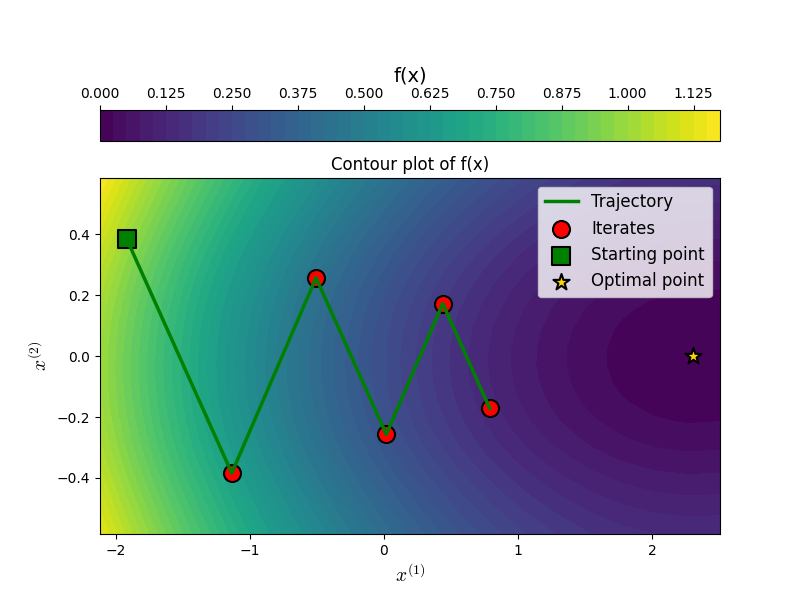

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Create figure and axes (2D now)
fig, ax = plt.subplots(figsize=(8,6))

# Contour plot
cont = ax.contourf(X, Y, FX, levels=50, cmap='viridis')

# Extract x, y from x_list_evaluated
x_pts = np.array([arr[0] for arr in x_list_evaluated])
y_pts = np.array([arr[1] for arr in x_list_evaluated])

# Overlay evaluated points (more visible)
ax.plot(
    x_pts[:-1],
    y_pts[:-1],
    color='green',
    linewidth=2.5,
    label='Trajectory'
)
ax.scatter(
    x_pts[:-1],
    y_pts[:-1],
    color='red',
    s=150,
    edgecolors='black',
    linewidths=1.5,
    marker='o',
    label='Iterates'
)
ax.scatter(
    x_pts[0],
    y_pts[0],
    color='green',
    s=150,
    edgecolors='black',
    linewidths=1.5,
    marker='s',
    label='Starting point'
)
ax.scatter(
    x_pts[-1],
    y_pts[-1],
    color='gold',
    s=150,
    edgecolors='black',
    linewidths=1.5,
    marker='*',
    label='Optimal point'
)

# Color bar
cbar = fig.colorbar(cont, ax=ax, orientation='horizontal', location='top', pad=0.08, label='f(x)')

# Labels
ax.set_xlabel(r'$x^{(1)}$')
ax.set_ylabel(r'$x^{(2)}$')

# Title
ax.set_title('Contour plot of f(x)')

ax.legend()

plt.show()

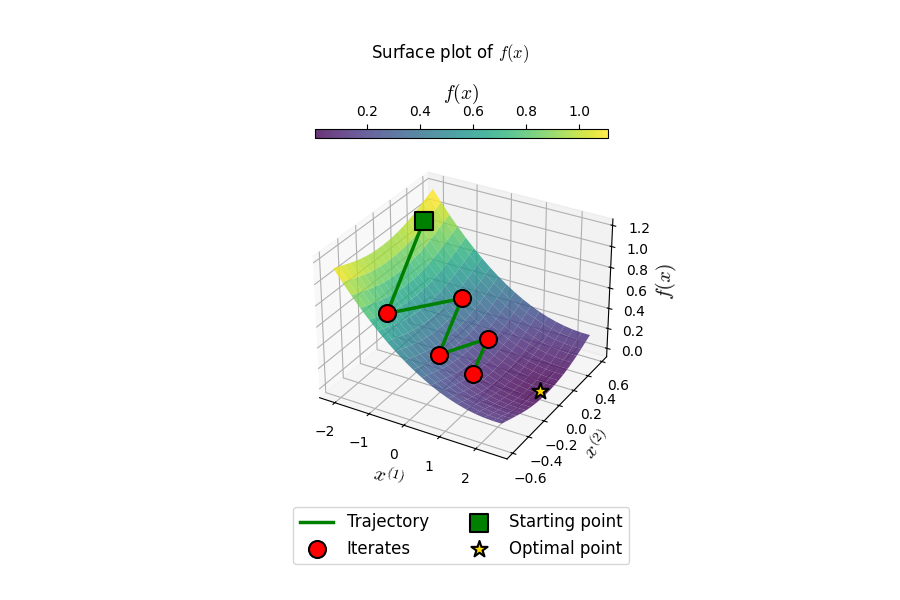

In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

# Create figure and 3D axes
fig = plt.figure(figsize=(9,6))
ax = fig.add_subplot(111, projection='3d', computed_zorder=False)

# Plot the surface
surf = ax.plot_surface(
    X, Y, FX,
    cmap='viridis',
    edgecolor='none',
    alpha=0.8,
    zorder=0
)

# Extract x, y from x_list_evaluated
x_pts = np.array([arr[0] for arr in x_list_evaluated])
y_pts = np.array([arr[1] for arr in x_list_evaluated])
z_pts = np.array(f_list_evaluated)

# Overlay evaluated points (more visible)
ax.plot(
    x_pts[:-1],
    y_pts[:-1],
    z_pts[:-1],
    color='green',
    linewidth=2.5,
    zorder=5,
    label='Trajectory'
)
ax.scatter(
    x_pts[:-1],
    y_pts[:-1],
    z_pts[:-1],
    color='red',
    s=150,
    edgecolors='black',
    linewidths=1.5,
    depthshade=False,
    marker='o',
    zorder=10,
    label='Iterates'
)
ax.scatter(
    x_pts[0],
    y_pts[0],
    z_pts[0],
    color='green',
    s=150,
    edgecolors='black',
    linewidths=1.5,
    depthshade=False,
    marker='s',
    zorder=10,
    label='Starting point'
)
ax.scatter(
    x_pts[-1],
    y_pts[-1],
    z_pts[-1],
    color='gold',
    s=150,
    edgecolors='black',
    linewidths=1.5,
    depthshade=False,
    marker='*',
    zorder=10,
    label='Optimal point'
)

# Add color bar
fig.colorbar(surf, ax=ax, orientation='horizontal', location='top', pad=0.02, shrink=0.42, aspect=30, label='$f(x)$')

# Labels
ax.set_xlabel(r'$x^{(1)}$')
ax.set_ylabel(r'$x^{(2)}$')
ax.set_zlabel('$f(x)$')

# Title
fig.suptitle('Surface plot of $f(x)$', y=0.93)

ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.08), ncol=2, borderaxespad=0.)
fig.subplots_adjust(bottom=0.2, top=0.87)

plt.show()

<div align="right"><a href="#toc">↩ Back to TOC</a></div>